### **CHSH - GAME**

In [ ]:
import random
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

#### **CLASSICAL STRATEGY IMPLEMENTATION**

In [13]:
def cplayer_output(strategy,inp):
    if strategy == 1:
        return inp
    elif strategy == 2:
        return abs(inp-1)
    elif strategy == 3:
        return 1
    elif strategy == 4:
        return 0
    else:
        print('Invalid input')
        

count_total_game = 10000
count_win = 0

# Pick Alice's classical strategy
A_st = int(input('select the classical strategy for Alice, input 1,2,3 or 4 to pick one of the strategies listed above '))
# Pick Bob's classical strategy
B_st = int(input('select the classical strategy for Bob, input 1,2,3 or 4 to pick one of the strategies listed above '))


for i in range(count_total_game):
    x = random.randint(0,1)
    y = random.randint(0,1)
    
    a = cplayer_output(A_st,x)
    b = cplayer_output(B_st,y)
    
    if (a^b) == (x&y): 
        count_win += 1
        
prob_win = count_win/count_total_game
print('Alice and Bob won the game with probability: ', prob_win*100,'%')

Alice and Bob won the game with probability:  75.0 %


#### **QUANTUM STRATEGY IMPLEMENTATION**

In [9]:
def qAlice_output(strategy,inp):
    if strategy == 1:
        return 0
    elif strategy == 2:
        return random.uniform(0,2*np.pi)
    elif strategy == 3:
        if inp == 0:
            return 0
        else:
            return np.pi/2
    else:
        print("Invalid choice")
        return 100

def qBob_output(strategy,inp):
    if strategy == 1:
        return 0
    elif strategy == 2:
        return random.uniform(0,2*np.pi)
    elif strategy == 3:
        if inp == 0:
            return np.pi/4
        else:
            return -np.pi/4
    else:
        print("Invalid choice")
        return 100
    

count_total_game = 10000
count_win = 0

# Pick Alice's classical strategy
qA_st = int(input('select the classical strategy for Alice, input 1,2,3 or 4 to pick one of the strategies listed above '))
# Pick Bob's classical strategy
qB_st = int(input('select the classical strategy for Bob, input 1,2,3 or 4 to pick one of the strategies listed above '))

simulator = AerSimulator()

for i in range(count_total_game):   
    x = random.randint(0,1)
    y = random.randint(0,1)
    
    angle_A = qAlice_output(qA_st,x)
    angle_B = qBob_output(qB_st,y)
    
    game = QuantumCircuit(2,2)
    game.h(0)
    game.cx(0,1)
    game.ry(angle_A,0)
    game.ry(angle_B,1)
    game.measure_all()
    
    counts = simulator.run(game,shots = 1).result().get_counts()
    outcome = list(counts.keys())[0]
    
    a = int(outcome[1])
    b = int(outcome[0])
    
    if (a^b) == (x&y):
        count_win += 1
        
prob_win = count_win/count_total_game
print(f"Alice's Strategy Choice: {qA_st} | Bob's Strategy Choice: {qB_st}")
print(f"Quantum Win Rate: {prob_win * 100:.2f}%")
print("Classical Maximum Bound Limit: 75.00%")
print("Theoretical Quantum Maximum:  ~85.35%")

Alice's Strategy Choice: 3 | Bob's Strategy Choice: 3
Quantum Win Rate: 86.22%
Classical Maximum Bound Limit: 75.00%
Theoretical Quantum Maximum:  ~85.35%


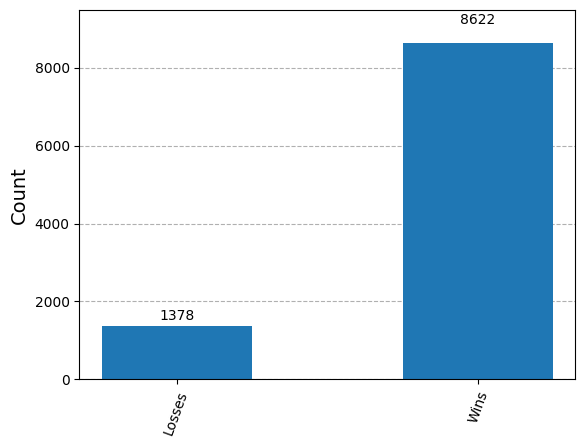

In [ ]:
game_results = {
    "Wins": count_win,
    "Losses": count_total_game - count_win
}

plot_histogram(game_results)